In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.style.use('seaborn-v0_8-whitegrid')

from src.testcases.taylor_green import exact_solution


In [2]:
path = "lbm_taylor_green_20251126_180401.npz"  # gaussian

data = np.load(path, allow_pickle=True)

meta = data["meta"].item()
config = meta["config"]
#print(config)

qtm_traj = data["quantum_traj"].item()
qtm_F = qtm_traj["F"]
qtm_rho = qtm_traj["rho"]
qtm_u = qtm_traj["u"]

cls_traj = data["classical_traj"].item()
cls_F = cls_traj["F"]
cls_rho = cls_traj["rho"]
cls_u = cls_traj["u"]

In [3]:
config

{'grid_size': (256, 256),
 'lattice': 'D2Q9',
 'is_scalar_field': False,
 'u_max': np.float64(0.05773502691896258),
 'u0': array([0., 0.])}

In [4]:
print(config["u0"])
print(config["u_max"])
#print(config["u_adv"])
#print(config["x0"])

[0. 0.]
0.05773502691896258


In [5]:
exact_u_t, exact_rho_t = exact_solution(u_max=config["u_max"])


exact_u = np.array([exact_u_t(t) for t in 20*np.arange(qtm_u.shape[0])])
exact_rho = np.array([exact_rho_t(t) for t in 20*np.arange(qtm_rho.shape[0])])

In [6]:
## Unweighted Velocity error
qtm_vel_er = np.linalg.norm(qtm_u - exact_u, axis=-1)
cls_vel_er = np.linalg.norm(cls_u - exact_u, axis=-1)
exact_vel = np.linalg.norm(exact_u, axis=-1)
qtm_vel_rel = np.sum(qtm_vel_er, axis=(1,2)) / np.sum(exact_vel, axis=(1,2))
cls_vel_rel = np.sum(cls_vel_er, axis=(1,2)) / np.sum(exact_vel, axis=(1,2))

print(qtm_vel_rel.round(4))

## Density (Scalar) error
qtm_rho_er = abs(qtm_rho - exact_rho)
cls_rho_er = abs(cls_rho - exact_rho)
qtm_rho_rel = np.sum(qtm_rho_er, axis=(1, 2)) / np.sum(exact_rho, axis=(1, 2))
cls_rho_rel = np.sum(cls_rho_er, axis=(1, 2)) / np.sum(exact_rho, axis=(1, 2))

print(qtm_rho_rel.round(4))

[0.     0.0188 0.0318 0.0348 0.0271 0.0117 0.0107 0.0251 0.0336 0.0319
 0.0204 0.0049 0.0164 0.0297 0.0336 0.0269 0.0122 0.0081 0.0231 0.0319
 0.0309 0.0206 0.0069 0.0143 0.0274 0.0321 0.0267 0.0131 0.0055 0.0209
 0.0302 0.03   0.0207 0.007  0.0126 0.0255 0.0306 0.0263 0.0139 0.0035
 0.0188 0.0285 0.0292 0.0208 0.0064 0.0109 0.0236 0.0292 0.0258 0.0146
 0.0038 0.0168 0.0267 0.0282 0.0209 0.0072 0.0089 0.0218 0.0278 0.0252
 0.015  0.0043 0.015  0.0249 0.0272 0.0209 0.0082 0.0072 0.02   0.0265
 0.0247 0.0153 0.0037 0.0133 0.0233 0.0261 0.0208 0.0091 0.0057 0.0182
 0.0251 0.0241 0.0156 0.0029 0.0117 0.0218 0.025  0.0205 0.0098 0.0044
 0.0165 0.0237 0.0234 0.0158 0.0035 0.0101 0.0202 0.024  0.0203 0.0103
 0.0036 0.015  0.0223 0.0227 0.016  0.0045 0.0086 0.0187 0.0229 0.0199
 0.0108 0.0024 0.0135 0.021  0.0219 0.0161 0.0054 0.0073 0.0172 0.0218
 0.0196 0.0113 0.0013 0.0121 0.0197 0.0212 0.016  0.0061 0.006  0.0158
 0.0207 0.0192 0.0116 0.0008 0.0107 0.0184 0.0204 0.016  0.0067 0.0049
 0.014

In [7]:
H, V = config["grid_size"]
assert H == V
L = H
L

256

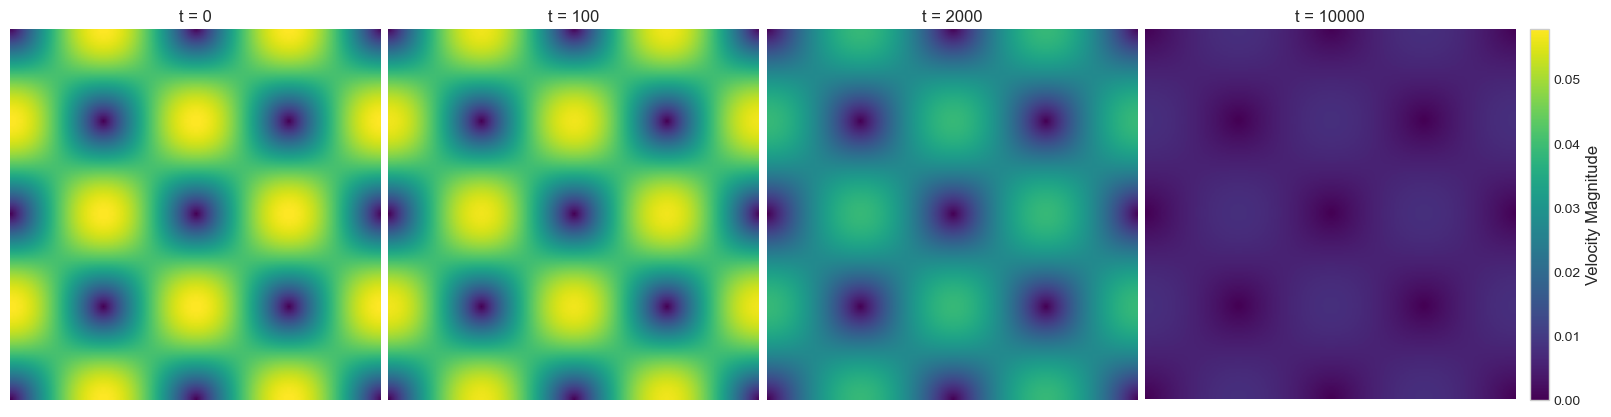

In [8]:
# Settings
indices = [0, 5, 100, 500]

# Horizontal layout
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharey=True, constrained_layout=True)

# Color Scaling: Use global min/max for all subplots to ensure consistency
qtm_u_norm = np.linalg.norm(qtm_u, axis=-1)
#qtm_u_norm = exact_rho
global_max, global_min = qtm_u_norm.max(), qtm_u_norm.min()

for ax, t_idx in zip(axes, indices):
    data = qtm_u_norm[t_idx]

    # A. Plot Field
    im = ax.imshow(data, origin='lower', extent=[0, L, 0, L],
                   vmin=global_min, vmax=global_max, cmap='viridis')
    ax.axis('off')

    # D. Formatting
    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(direction='in', color='white')
    ax.grid(False)
    ax.set_title(f"t = {20*t_idx}", fontsize=12)

# Colorbar
cbar = fig.colorbar(im, orientation='vertical', fraction=0.05, pad=0.04)

cbar.set_label('Velocity Magnitude', fontsize=12)
#cbar.set_ticks([])

plt.savefig("taylor_green_field.pdf", format="pdf", bbox_inches="tight")
plt.show()

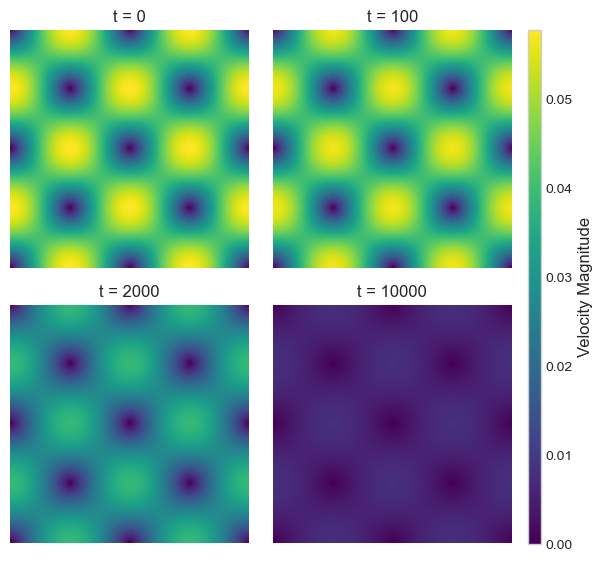

In [19]:
import matplotlib.pyplot as plt
import numpy as np

indices = [0, 5, 100, 500]

fig = plt.figure(figsize=(6, 5.5), constrained_layout=True)

# 2 rows, 3 columns (last column for colorbar)
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.05])

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
]

cax = fig.add_subplot(gs[:, 2])  # <-- spans both rows

# Color scaling
qtm_u_norm = np.linalg.norm(qtm_u, axis=-1)
global_min, global_max = qtm_u_norm.min(), qtm_u_norm.max()

for ax, t_idx in zip(axes, indices):
    data = qtm_u_norm[t_idx]

    im = ax.imshow(
        data,
        origin='lower',
        extent=[0, L, 0, L],
        vmin=global_min,
        vmax=global_max,
        cmap='viridis'
    )

    ax.set_title(f"t = {20*t_idx}", fontsize=12)
    ax.axis('off')

# Full-height colorbar
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Velocity Magnitude", fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.savefig("taylor_green_field.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [16]:
np.linalg.norm(qtm_u - exact_u, axis=-1).max()

np.float64(0.0020307678088850615)

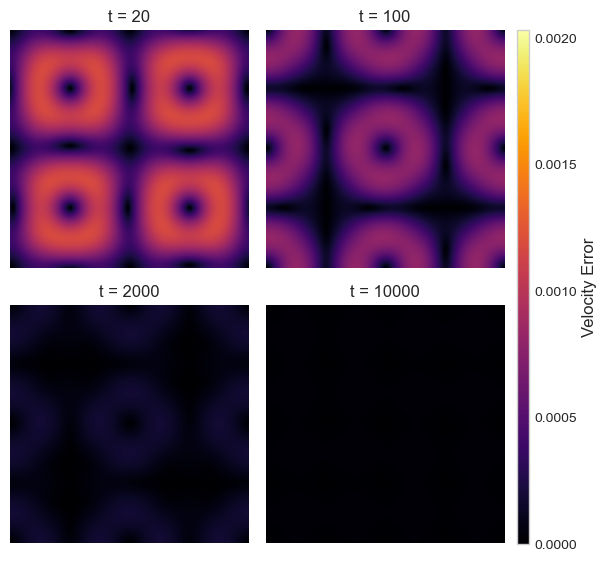

In [29]:
import matplotlib.pyplot as plt
import numpy as np

indices = [1, 5, 100, 500]

fig = plt.figure(figsize=(6, 5.5), constrained_layout=True)

# 2 rows, 3 columns (last column for colorbar)
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.05])

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
]

cax = fig.add_subplot(gs[:, 2])  # <-- spans both rows

# Color scaling
u_error_norm = np.linalg.norm(qtm_u - exact_u, axis=-1)
global_min = u_error_norm.min()
global_max = u_error_norm.max()

for ax, t_idx in zip(axes, indices):
    data = np.linalg.norm(qtm_u[t_idx] - exact_u[t_idx], axis=-1)

    im = ax.imshow(
        data,
        origin='lower',
        extent=[0, L, 0, L],
        vmin=global_min,
        vmax=global_max,
        cmap='inferno'
    )

    ax.set_title(f"t = {20*t_idx}", fontsize=12)
    ax.axis('off')

# Full-height colorbar
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Velocity Error", fontsize=12)
cbar.ax.tick_params(labelsize=10)
cbar.set_ticks([0., 0.0005, 0.001, 0.0015, 0.002])

plt.savefig("taylor_green_heatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()


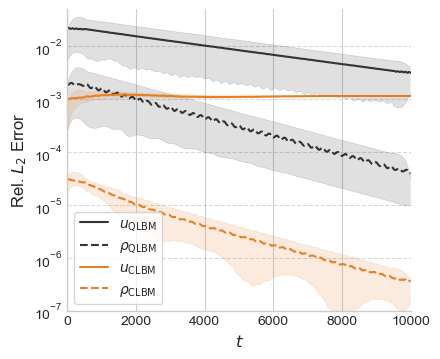

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks, savgol_filter
from scipy.interpolate import PchipInterpolator

# --- 1. The "Peak Envelope" Function ---
def get_smooth_envelope(t, y, peak_distance=1, smooth_window=51):
    """
    Creates a smooth upper/lower envelope by connecting local maxima/minima.
    """
    # A. Find Indices of Local Peaks and Valleys
    # distance=1 ensures we capture every local extreme to define the full envelope
    peaks, _ = find_peaks(y, distance=peak_distance)
    valleys, _ = find_peaks(-y, distance=peak_distance)

    # B. Force-include the start and end points
    # This ensures the envelope stretches across the entire time range
    peaks = np.unique(np.concatenate(([0], peaks, [len(y)-1])))
    valleys = np.unique(np.concatenate(([0], valleys, [len(y)-1])))

    # C. Interpolate to create smooth boundary lines
    # PchipInterpolator is better than CubicSpline here because it
    # prevents "overshoot" (wild oscillations) between peaks.
    upper_interp = PchipInterpolator(t[peaks], y[peaks])
    lower_interp = PchipInterpolator(t[valleys], y[valleys])

    upper_line = upper_interp(t)
    lower_line = lower_interp(t)

    # D. Optional: Final Polish (Savgol Filter)
    # Irons out small kinks where the line hits a peak
    if len(upper_line) > smooth_window:
        upper_line = savgol_filter(upper_line, smooth_window, 3)
        lower_line = savgol_filter(lower_line, smooth_window, 3)

    # E. Calculate Central Trend (Rolling Mean)
    # A centered rolling mean represents the "average" behavior best
    trend = pd.Series(y).rolling(window=50, center=True, min_periods=1).mean().values

    # Clip lower bound to avoid log-scale issues (cannot go <= 0)
    lower_line = np.maximum(lower_line, 1e-16)

    return lower_line, upper_line, trend

# --- 2. Setup Plot ---
fig, ax = plt.subplots(figsize=(4.5, 3.7))
c_qtm = '#333333'  # dark Gray
c_cls = '#E67E22'  # orange

# --- 3. Plotting Function ---
def plot_tube(t, data, color, label, linestyle='-'):
    lower, upper, trend = get_smooth_envelope(t, data)

    # 1. The Fill (The "Tube")
    ax.fill_between(t, lower, upper, color=color, alpha=0.15,
                    edgecolor=None, zorder=1)

    # 2. The Envelope Edges (Optional: adds a thin "technical" border)
    ax.plot(t, lower, color=color, linewidth=0.3, alpha=0.3, zorder=1)
    ax.plot(t, upper, color=color, linewidth=0.3, alpha=0.3, zorder=1)

    # 3. The Trend Line (Solid/Dashed center)
    ax.plot(t, trend, label=label, color=color,
            linestyle=linestyle, linewidth=1.5, zorder=2)

# --- 4. Execute on your data ---
# (Assuming your variables 'times', 'qtm_vel_rel', etc. are loaded)

times = 20 * np.arange(qtm_rho.shape[0])  # Time steps corresponding to data

plot_tube(times, qtm_vel_rel, c_qtm, r"$u_{\mathrm{QLBM}}$", '-')
plot_tube(times, qtm_rho_rel, c_qtm, r"$\rho_{\mathrm{QLBM}}$", '--')

plot_tube(times, cls_vel_rel, c_cls, r"$u_{\mathrm{CLBM}}$", '-')
plot_tube(times, cls_rho_rel, c_cls, r"$\rho_{\mathrm{CLBM}}$", '--')

# --- 5. Styling ---
ax.set_yscale('log')
ax.set_xlim(0, 10000)
ax.set_ylim(1e-7, 0.05)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
#ax.spines['left'].set_color('#444444')
#ax.spines['bottom'].set_color('#444444')

ax.grid(True, which='major', axis='y', linestyle='--', alpha=0.3, color='gray')
ax.set_xlabel('$t$', fontsize=12)
ax.set_ylabel('Rel. $L_2$ Error', fontsize=12)
ax.tick_params(axis='both', labelsize=10)

ax.legend(loc='lower left', frameon=True, fontsize=10)

plt.tight_layout()
plt.savefig('taylor_green_error.pdf', format='pdf', bbox_inches='tight')
plt.show()